# H.E.S.S. II (CT5)

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope, show_image, show_sensor_chain, show_telescope

## Load telescope and camera

In [2]:
telescope = Telescope.from_yaml(
    "../../configs/HESS/CT5.yaml",
    n_samples=64,
    key=jax.random.key(42),
)
flashcam = Camera.from_yaml("../../configs/HESS/FlashCam.yaml")
hess2cam = Camera.from_yaml("../../configs/HESS/HESS2Cam.yaml")

E0804 10:49:37.462997 3116308 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0804 10:49:37.463143 3116309 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0804 10:49:37.463197 3116310 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


In [3]:
telescope = telescope.apply_roughness(0, 24)

## 3D scene

In [4]:
scene = show_telescope(telescope)
scene.show(viewer="jupyter")

In [5]:
scene = show_sensor_chain(flashcam)
scene.show(viewer="jupyter")

## Star field on both cameras

Text(0.5, 1.0, 'HESS-II camera')

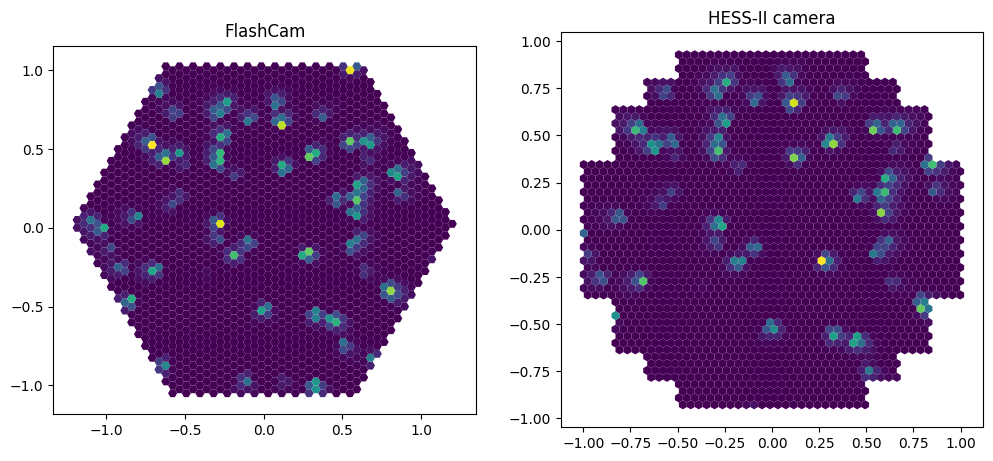

In [6]:
n_stars = 100
key1, key2 = jax.random.split(jax.random.key(45))

fov_deg = 4
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

f_stars = jax.random.uniform(jax.random.key(42), shape=(len(stars),))

rays = telescope.render(stars, f_stars, source_type="parallel")
image_flashcam = flashcam.image(rays)
image_hess2 = hess2cam.image(rays)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
show_image(image_flashcam, flashcam.sensor_groups[0], ax=ax[0])
show_image(image_hess2, hess2cam.sensor_groups[0], ax=ax[1])
ax[0].set_title("FlashCam")
ax[1].set_title("HESS-II camera")

## Bokeh from a finite-distance point source

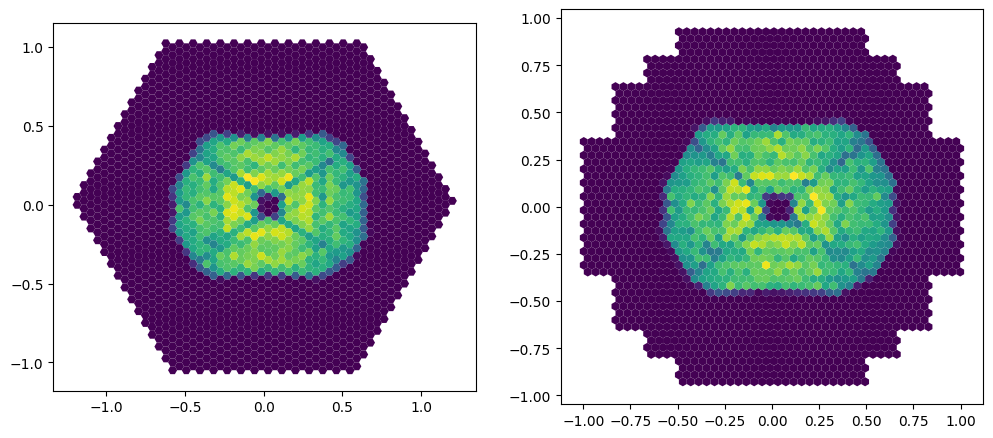

In [7]:
N_points = 1
key1, key2 = jax.random.split(jax.random.key(12))

x = jax.random.uniform(key1, N_points, minval=-1, maxval=1)
y = jax.random.uniform(key2, N_points, minval=-1, maxval=1)
z = jnp.ones(N_points) * 1000

points = jnp.array([x, y, z]).T
f_points = jnp.ones(len(points))

rays = telescope.render(points, f_points, source_type="point")
image_flashcam = flashcam.image(rays)
image_hess2 = hess2cam.image(rays)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
ax1 = show_image(image_flashcam, flashcam.sensor_groups[0], ax=ax[0])
ax2 = show_image(image_hess2, hess2cam.sensor_groups[0], ax=ax[1])

## Spot diagram from explicit ray geometry

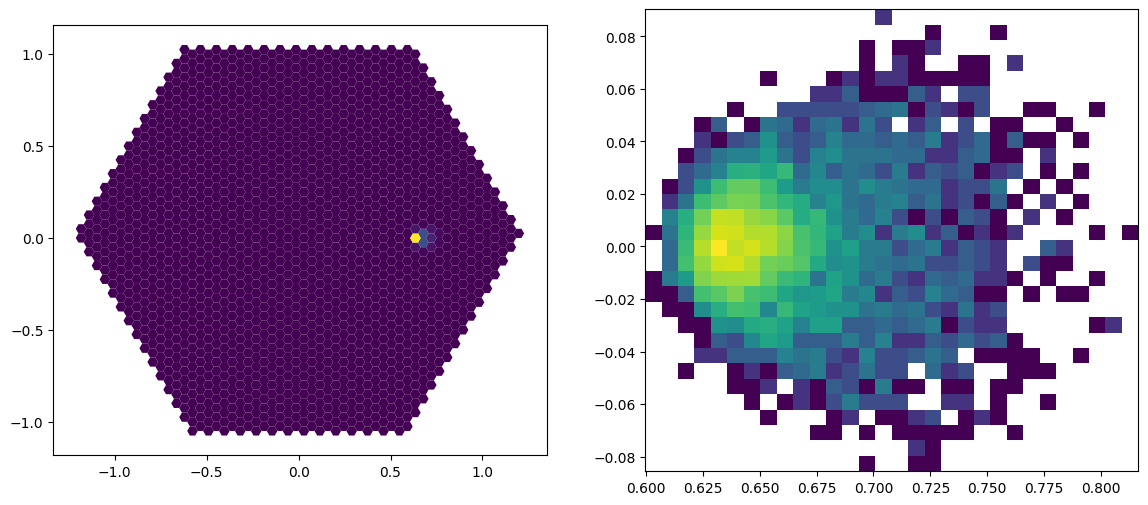

In [8]:
from iactrace.analysis import FlatFocalPlane

n_rays = 10000
key1, key2 = jax.random.split(jax.random.key(123))

r = 20.0 * jnp.sqrt(jax.random.uniform(key1, (n_rays,)))
theta = jax.random.uniform(key2, (n_rays,)) * 2 * jnp.pi
ray_origins = jnp.stack(
    [r * jnp.cos(theta), r * jnp.sin(theta), jnp.ones(n_rays) * 100.0],
    axis=1,
)

tilt_angle = 1.0 * jnp.pi / 180
ray_directions = jnp.broadcast_to(
    jnp.array([jnp.sin(tilt_angle), 0.0, -jnp.cos(tilt_angle)]),
    (n_rays, 3),
)
ray_values = jnp.ones(n_rays)

rays, traj = telescope.trace(ray_origins, ray_directions, ray_values)
image = flashcam.image(rays)

focal_plane = FlatFocalPlane()
hits = focal_plane.intersect(rays)

fig, ax = plt.subplots(ncols=2, figsize=(14, 6))
show_image(image, flashcam.sensor_groups[0], ax=ax[0])
h2 = ax[1].hist2d(
    hits.xy_local[hits.alive, 0],
    hits.xy_local[hits.alive, 1],
    bins=30,
    norm="log",
)